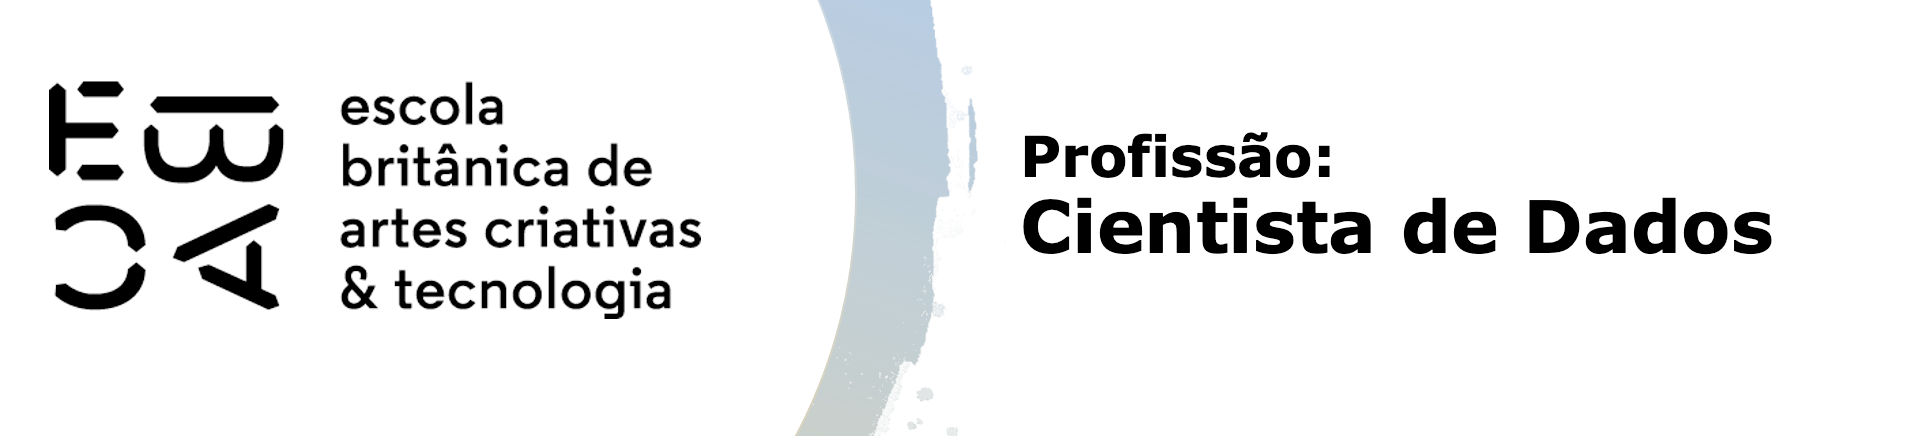

# Tarefa II

Ainda sobre a base da NFP vista na tarefa passada:

|Campo|Descrição|
|:-|:-|
|CNPJ emit.| CNPJ do emitente da nota|
|Emitente| Nome fantasia do emitente da nota|
|No.| Número da nota fiscal|
|Data Emissão| Data de emissão da nota fiscal|
|Valor NF| Valor da nota fiscal|
|Data Registro| Data de registro no sistema da NFP|
|Créditos| Valor dos créditos (doação)|
|Situação do Crédito| Se o crédito já foi pago, está sendo processado etc.|
|Ano| Ano da emissão da nota|
|Semestre| Semestre da emissão da nota|
|Retorno| Valor do crédito dividido pelo valor da nota|
|flag_credito| Indicadora se a nota possui crédito positivo|
|categoria| Categorização da nota |

**OBJETIVO:** Algumas notas não dão retorno, o que pode ocorrer por diversos motivos, um deles seria a ocorrência de produtos não incentivados como cigarros e bebidas alcólicas. O nosso objetivo é tentar prever que tipo de nota tem maior ou menor propensão a fornecer créditos.

**Observação**: Esta é uma base real, havendo características de acordo. Pode haver uma variabilidade difícil de explicar, em parte por causa de uma freqüência de notas inconstante no tempo (por diversos motivos), em parte por haverem informações importantes, protegidas pela LGPD, não constantes na base, que pode interferir no crédito gerado, o que vai ocasionar uma variabilidade difícil de se explicar. *Welcome to the jungle*, A vida real é assim :)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from babel.util import missing
from matplotlib.pyplot import subplot
import warnings;   warnings.filterwarnings("ignore")

In [2]:
df = pd.read_pickle('base_nfp.pkl')
df.head()

,CNPJ emit.,Emitente,No.,Data Emissão,Valor NF,Data Registro,Créditos,Situação do Crédito,Ano,Semestre,Retorno,flag_credito,categoria
0,03.476.811/0741-98,DIA BRASIL SOCIEDADE LIMITADA,537,2017-06-30,24.68,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Mercado
1,43.101.310/0001-05,AUTO POSTO ZANWAL LTDA EPP,2894,2017-06-30,50.00,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Auto posto
2,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,699,2017-06-30,27.00,2017-06-30,0.44,Liberado,2017,1,0.016296,1,Restaurantes
3,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,698,2017-06-30,111.50,2017-06-30,1.81,Liberado,2017,1,0.016233,1,Restaurantes
4,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,694,2017-06-30,125.00,2017-06-30,2.03,Liberado,2017,1,0.016240,1,Restaurantes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187646 entries, 0 to 187645
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   CNPJ emit.           187646 non-null  object        
 1   Emitente             187646 non-null  object        
 2   No.                  187646 non-null  int64         
 3   Data Emissão         187646 non-null  datetime64[ns]
 4   Valor NF             187646 non-null  float64       
 5   Data Registro        187646 non-null  datetime64[ns]
 6   Créditos             187646 non-null  float64       
 7   Situação do Crédito  187646 non-null  category      
 8   Ano                  187646 non-null  int64         
 9   Semestre             187646 non-null  int64         
 10  Retorno              186666 non-null  float64       
 11  flag_credito         187646 non-null  int64         
 12  categoria            187646 non-null  object        
dtypes: category(1)

In [4]:
df = pd.read_pickle('base_nfp.pkl')
df.set_index('Data Emissão', inplace=True)
df_2020 = df['2020-01-01':]

df_2020.dropna(inplace=True)
df_2020.reset_index(inplace=True)
print(df_2020.head())

  Data Emissão          CNPJ emit.                                Emitente  \
0   2020-01-01  05.234.750/0001-41                          TX BURGER LTDA   
1   2020-01-01  47.508.411/1476-88          CIA BRASILEIRA DE DISTRIBUICAO   
2   2020-01-01  09.060.964/0108-39            PIMENTA VERDE ALIMENTOS LTDA   
3   2020-01-01  61.412.110/0307-39                  DROGARIA SAO PAULO S A   
4   2020-01-01  46.952.032/0001-98  PANIFICADORA E CONFEITARIA QUELUZ LTDA   

      No.  Valor NF Data Registro  Créditos Situação do Crédito   Ano  \
0   77882     78.80    2020-08-01       0.0          A Calcular  2019   
1   20087     22.71    2020-01-01       0.0          A Calcular  2019   
2   82366     35.90    2020-08-01       0.0          A Calcular  2019   
3  234178     21.77    2020-08-01       0.0          A Calcular  2019   
4    3305     80.95    2020-08-01       0.0          A Calcular  2019   

   Semestre  Retorno  flag_credito     categoria  
0         2      0.0             0  não d

## Criando variáveis

**Variáveis temporais**: É possível que haja alguma regra de liberação de créditos de acordo com o dia do mês, o dia da semana, fim de semana (sim ou não), ou até alterações temporais da regra. Vamos criar as seguintes variáveis para testar estas hipóteses:

- Dia da semana
- Dummy para fim de semana
- Dia do mês
- Mês (já na base)
- Trimestre
- Ano (já na base)

**Valor da nota**: Vamos criar também algumas variáveis para resumir o valor da nota, e posteriormente criar uma intuição sobre categorizações de variáveis contínuas.

- Crie categorizações da variável ```Valor NF```, por quantís, em 5, 10, 20 e 50 categorias.

In [5]:
# Create temporal variables
df_2020['dia_semana'] = pd.to_datetime(df_2020['Data Emissão']).dt.day_name()
df_2020['fim_semana'] = pd.to_datetime(df_2020['Data Emissão']).dt.dayofweek.isin([5, 6]).astype(int)
df_2020['dia_mes'] = pd.to_datetime(df_2020['Data Emissão']).dt.day
df_2020['trimestre'] = pd.to_datetime(df_2020['Data Emissão']).dt.quarter
print(df_2020)

      Data Emissão          CNPJ emit.  \
0       2020-01-01  05.234.750/0001-41   
1       2020-01-01  47.508.411/1476-88   
2       2020-01-01  09.060.964/0108-39   
3       2020-01-01  61.412.110/0307-39   
4       2020-01-01  46.952.032/0001-98   
...            ...                 ...   
85995   2021-01-07  22.172.203/0004-40   
85996   2021-01-07  71.676.316/0005-70   
85997   2021-01-07  61.585.865/0240-93   
85998   2021-01-07  67.616.128/0001-55   
85999   2021-01-07  67.616.128/0001-55   

                                     Emitente     No.  Valor NF Data Registro  \
0                              TX BURGER LTDA   77882     78.80    2020-08-01   
1              CIA BRASILEIRA DE DISTRIBUICAO   20087     22.71    2020-01-01   
2                PIMENTA VERDE ALIMENTOS LTDA   82366     35.90    2020-08-01   
3                      DROGARIA SAO PAULO S A  234178     21.77    2020-08-01   
4      PANIFICADORA E CONFEITARIA QUELUZ LTDA    3305     80.95    2020-08-01   
...      

In [6]:
# Create value categories using qcut
df_2020['valor_nf_5cat'] = pd.qcut(df_2020['Valor NF'], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
df_2020['valor_nf_10cat'] = pd.qcut(df_2020['Valor NF'], q=10, labels=[f'D{i}' for i in range(1, 11)])
df_2020['valor_nf_20cat'] = pd.qcut(df_2020['Valor NF'], q=20, labels=[f'V{i}' for i in range(1, 21)])
df_2020['valor_nf_50cat'] = pd.qcut(df_2020['Valor NF'], q=50, labels=[f'C{i}' for i in range(1, 51)])
print(df_2020)

      Data Emissão          CNPJ emit.  \
0       2020-01-01  05.234.750/0001-41   
1       2020-01-01  47.508.411/1476-88   
2       2020-01-01  09.060.964/0108-39   
3       2020-01-01  61.412.110/0307-39   
4       2020-01-01  46.952.032/0001-98   
...            ...                 ...   
85995   2021-01-07  22.172.203/0004-40   
85996   2021-01-07  71.676.316/0005-70   
85997   2021-01-07  61.585.865/0240-93   
85998   2021-01-07  67.616.128/0001-55   
85999   2021-01-07  67.616.128/0001-55   

                                     Emitente     No.  Valor NF Data Registro  \
0                              TX BURGER LTDA   77882     78.80    2020-08-01   
1              CIA BRASILEIRA DE DISTRIBUICAO   20087     22.71    2020-01-01   
2                PIMENTA VERDE ALIMENTOS LTDA   82366     35.90    2020-08-01   
3                      DROGARIA SAO PAULO S A  234178     21.77    2020-08-01   
4      PANIFICADORA E CONFEITARIA QUELUZ LTDA    3305     80.95    2020-08-01   
...      

## Calcule o IV de todas essas variáveis

Sugestão: Construa um metadados e tente utilizar uma função como a que foi utilizada durante a aula. Você vai conseguir fazer esse cálculo para as variáveis uma a uma, mas em casos reais em que vamos mais além na criação de variáveis, podemos ter centenas, ou até milhares de variáveis, esses cálculos *precisam* ser automáticos nesses casos.

In [7]:
df_2020_short = df_2020.drop(columns=[
    'Data Emissão',
    'CNPJ emit.',
    'Emitente',
    'No.',
    'Valor NF',
    'Data Registro',
    'Créditos',
    'Situação do Crédito',
    'Retorno'
])

metadados = pd.DataFrame({'dtype': df_2020_short.dtypes})
metadados

,dtype
Ano,int64
Semestre,int64
flag_credito,int64
categoria,object
dia_semana,object
fim_semana,int64
dia_mes,int32
trimestre,int32
valor_nf_5cat,category
valor_nf_10cat,category


In [8]:
metadados['papel'] = 'covariavel'
metadados.loc['flag_credito', 'papel'] = 'resposta'
metadados['nunique'] = df_2020.nunique()
metadados

,dtype,papel,nunique
Ano,int64,covariavel,3
Semestre,int64,covariavel,2
flag_credito,int64,resposta,2
categoria,object,covariavel,9
dia_semana,object,covariavel,7
fim_semana,int64,covariavel,2
dia_mes,int32,covariavel,31
trimestre,int32,covariavel,4
valor_nf_5cat,category,covariavel,5
valor_nf_10cat,category,covariavel,10


In [9]:
def IV(variavel, resposta):
    tab = pd.crosstab(variavel, resposta, margins=True, margins_name='total')

    rotulo_evento = tab.columns[0]
    rotulo_nao_evento = tab.columns[1]

    tab['pct_evento'] = tab[rotulo_evento]/tab.loc['total', rotulo_evento]
    tab['pct_nao_evento'] = tab[rotulo_nao_evento]/tab.loc['total', rotulo_nao_evento]
    tab['woe'] = np.log(tab.pct_evento/tab.pct_nao_evento)
    tab['iv_parcial'] = (tab.pct_evento - tab.pct_nao_evento)*tab.woe
    return tab['iv_parcial'].sum()

In [10]:
for var in metadados[metadados.papel == 'covariavel'].index:
    if (metadados.loc[var, 'nunique'] > 50):
        metadados.loc[var, 'IV'] = IV(
            pd.qcut(df_2020_short[var], 5, duplicates='drop'), df_2020_short.flag_credito)
    else:
        metadados.loc[var, 'IV'] = IV(
            df_2020_short[var], df_2020_short.flag_credito)

metadados

,dtype,papel,nunique,IV
Ano,int64,covariavel,3,inf
Semestre,int64,covariavel,2,0.003679
flag_credito,int64,resposta,2,NaN
categoria,object,covariavel,9,0.240964
dia_semana,object,covariavel,7,0.006784
fim_semana,int64,covariavel,2,0.005311
dia_mes,int32,covariavel,31,0.012432
trimestre,int32,covariavel,4,0.003010
valor_nf_5cat,category,covariavel,5,0.044709
valor_nf_10cat,category,covariavel,10,0.056499


In [11]:
metadados.loc[metadados['IV'] >= 0, 'poder_preditivo'] = 'Inutil'
metadados.loc[(metadados['IV'] > 0.02) & (metadados['IV'] <= 0.1), 'poder_preditivo'] = 'Fraco'
metadados.loc[(metadados['IV'] > 0.1) & (metadados['IV'] <= 0.3), 'poder_preditivo'] = 'Medio'
metadados.loc[(metadados['IV'] > 0.3) & (metadados['IV'] <= 0.5), 'poder_preditivo'] = 'Forte'
metadados.loc[(metadados['IV'] > 0.5), 'poder_preditivo'] = 'Super alto - Atencao'
metadados

,dtype,papel,nunique,IV,poder_preditivo
Ano,int64,covariavel,3,inf,Super alto - Atencao
Semestre,int64,covariavel,2,0.003679,Inutil
flag_credito,int64,resposta,2,NaN,NaN
categoria,object,covariavel,9,0.240964,Medio
dia_semana,object,covariavel,7,0.006784,Inutil
fim_semana,int64,covariavel,2,0.005311,Inutil
dia_mes,int32,covariavel,31,0.012432,Inutil
trimestre,int32,covariavel,4,0.003010,Inutil
valor_nf_5cat,category,covariavel,5,0.044709,Fraco
valor_nf_10cat,category,covariavel,10,0.056499,Fraco


## Conclua

- Quais variáveis parecem apresentar maior poder de discriminação segundo o IV?
- Quando categorizamos variáveis contínuas parece haver alguma relação entre o número de categorias e o IV?

* segundo o IV  as variaveis que apresenta o maior pode descrinacao e a variavel poder_preditivo que soma
41.7% inutil e fraco 33.3 ja other 25%
*

## Descritiva simples no tempo

Para compor a análise que virá a seguir, faça uma análise descritiva básica no tempo - utilize trimestre como agregação (ou uma média móvel por trimestre, como preferir) e avalie graficamente:

- A quantidade de notas registradas na base por período
- A quantidade de notas por categoria e por período
- A proporção de notas com crédito por categoria por período

In [12]:
df_2020_2 = df_2020.groupby(['trimestre', 'flag_credito']).size().unstack(fill_value=0)
df_2020_2['soma'] = df_2020_2.sum(axis=1)
df_2020_2

flag_credito,0,1,soma
trimestre,,,
1,11397,9146,20543
2,11847,8231,20078
3,12377,9720,22097
4,13061,10221,23282


In [13]:
df_2020_3 = df_2020.groupby(['trimestre', 'categoria', 'flag_credito']).size().unstack(fill_value=0)
df_2020_3['soma'] = df_2020_3.sum(axis=1)
df_2020_3['tx_evento'] = df_2020_3[1]/df_2020_3[0]
df_2020_3.head()

flag_credito             0     1  soma  tx_evento
trimestre categoria                              
1         Alimentos    374   908  1282   2.427807
          Auto posto   118    34   152   0.288136
          Construção  2041  1811  3852   0.887310
          Farmácia    1794   638  2432   0.355630
          Mercado     3456  3271  6727   0.946470

<Axes: xlabel='categoria', ylabel='soma'>

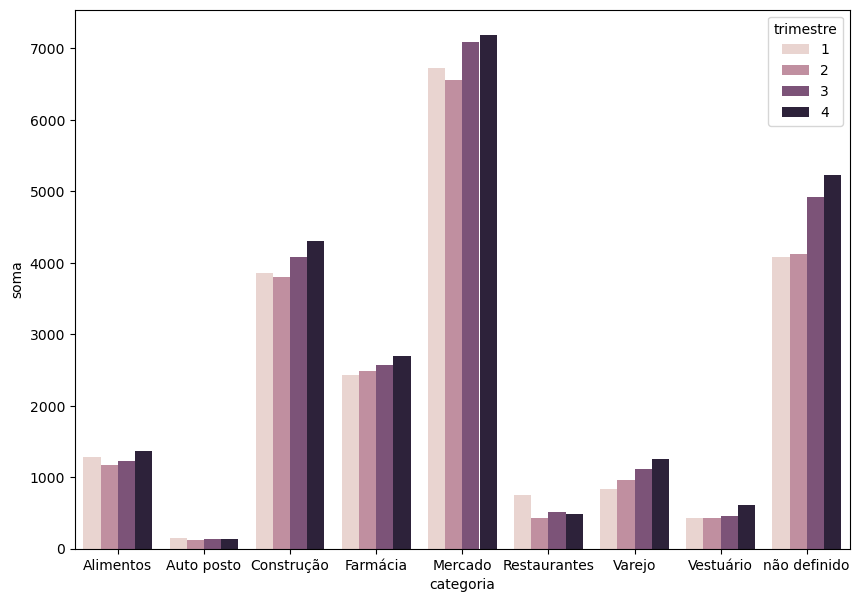

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(data=df_2020_3.reset_index(), x='categoria',y='soma', hue='trimestre', ci=None, ax=ax)

In [15]:
df_2020_3 = df_2020.groupby(['trimestre', 'categoria', 'flag_credito']).size().unstack(fill_value=0)
df_2020_3['soma'] = df_2020_3.sum(axis=1)
df_2020_3['tx_evento'] = df_2020_3[1]/df_2020_3[0]
df_2020_3.head()

flag_credito             0     1  soma  tx_evento
trimestre categoria                              
1         Alimentos    374   908  1282   2.427807
          Auto posto   118    34   152   0.288136
          Construção  2041  1811  3852   0.887310
          Farmácia    1794   638  2432   0.355630
          Mercado     3456  3271  6727   0.946470

<Axes: xlabel='categoria', ylabel='soma'>

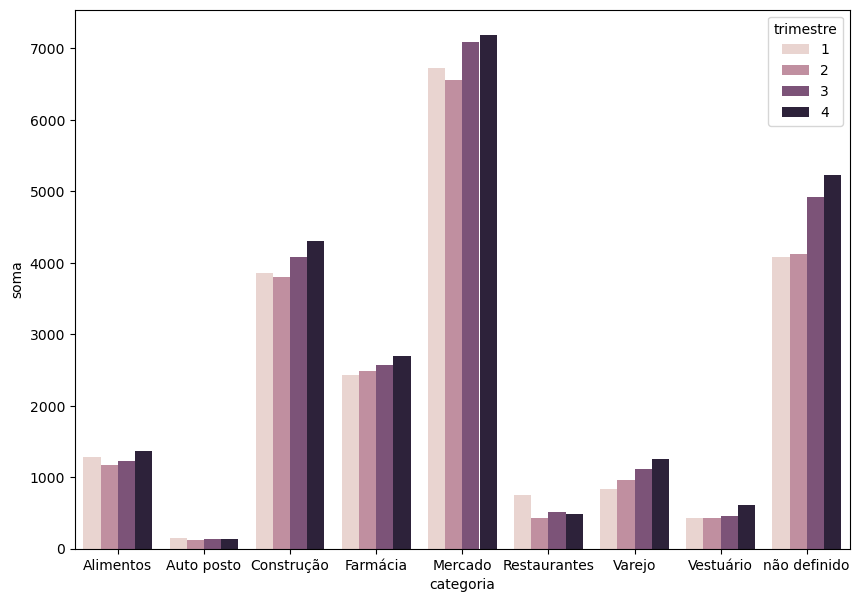

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(data=df_2020_3.reset_index(), x='categoria',y='soma', hue='trimestre', ci=None, ax=ax)

<Axes: xlabel='categoria', ylabel='tx_evento'>

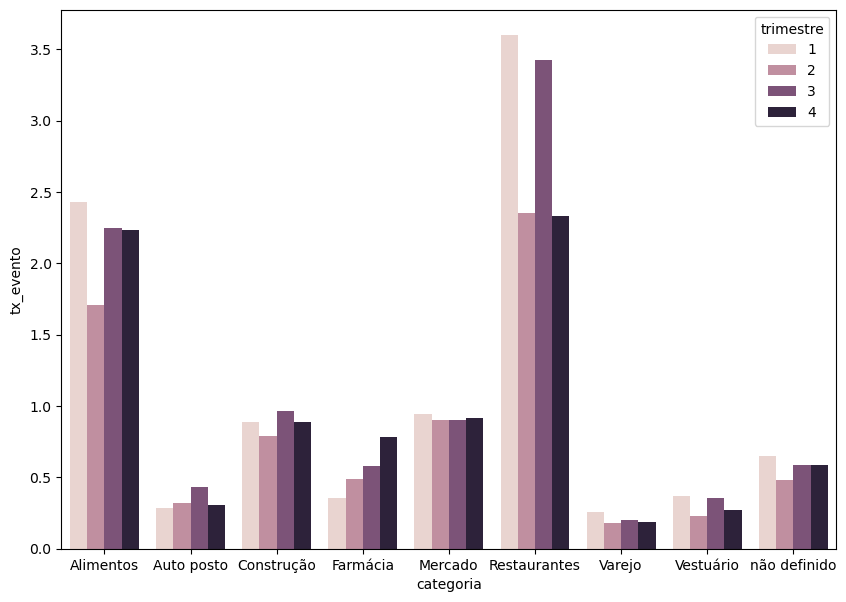

In [17]:
fig, ax = plt.subplots(figsize=(10,7))

sns.barplot(data=df_2020_3.reset_index(), x='categoria', y='tx_evento', hue = 'trimestre', ci=None, ax=ax)

## Avalie o WOE e o IV no tempo

Avalie o WOE e o IV no tempo da variável ```categoria```.

In [18]:
df_2020_3['pct_evento'] = df_2020_3[1]/df_2020_3[1].groupby(level=0).sum()
df_2020_3['pct_nao_evento'] = df_2020_3[0]/df_2020_3[0].groupby(level=0).sum()
df_2020_3['WOE'] = np.log(df_2020_3.pct_evento/df_2020_3.pct_nao_evento)
df_2020_3.head()

flag_credito             0     1  soma  tx_evento  pct_evento  pct_nao_evento  \
trimestre categoria                                                             
1         Alimentos    374   908  1282   2.427807    0.099278        0.032816   
          Auto posto   118    34   152   0.288136    0.003717        0.010354   
          Construção  2041  1811  3852   0.887310    0.198010        0.179082   
          Farmácia    1794   638  2432   0.355630    0.069757        0.157410   
          Mercado     3456  3271  6727   0.946470    0.357643        0.303238   

flag_credito               WOE  
trimestre categoria             
1         Alimentos   1.107022  
          Auto posto -1.024291  
          Construção  0.100473  
          Farmácia   -0.813831  
          Mercado     0.165017

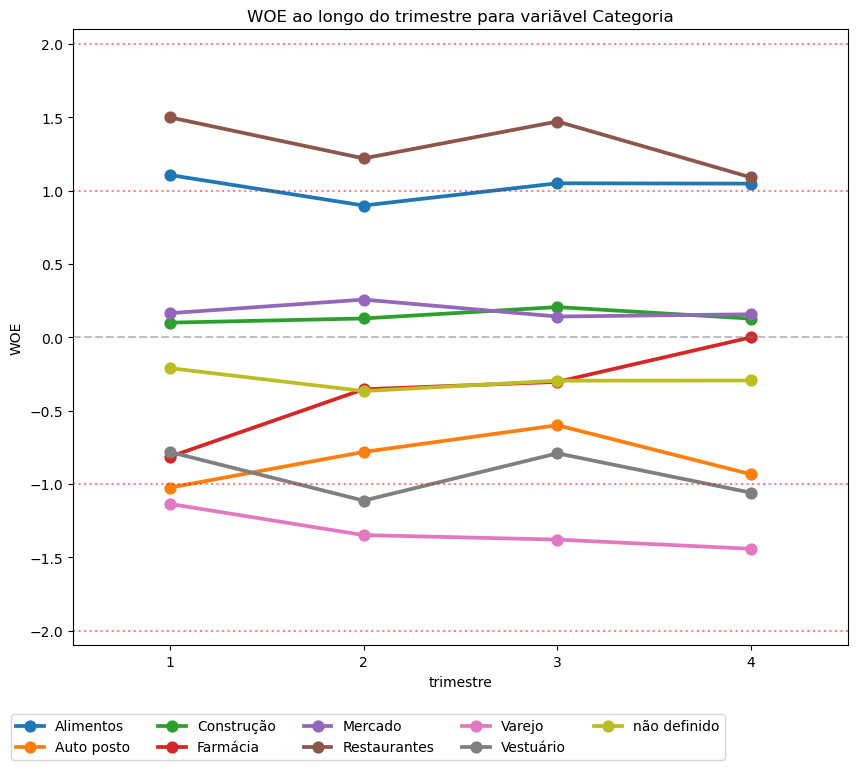

In [19]:
fig, ax = plt.subplots(figsize=(10,8))
variavel = 'categoria'

# Comando principal do gráfico
sns.pointplot(data=df_2020_3.reset_index(), y='WOE', x='trimestre', hue=variavel, ax=ax)

# limites do gráfico - mostrando 1 e -1 para ter referência
ymax = max(2.1, max(df_2020_3.WOE))
ymin = min(-2.1, min(df_2020_3.WOE))
ax.set_ylim([ymin, ymax])

# Linhas de referência
ax.axhline(2, linestyle=':', color='red', alpha=.5)
ax.axhline(1, linestyle=':', color='red', alpha=.5)
ax.axhline(0, linestyle='--', color='grey', alpha=.5)
ax.axhline(-1, linestyle=':', color='red', alpha=.5)
ax.axhline(-2, linestyle=':', color='red', alpha=.5)

# Títulos
ax.set_title(f'WOE ao longo do trimestre para variãvel {variavel.capitalize()}')
# ax.set_xlabel('Safra', loc='right')

ax.legend(bbox_to_anchor=(.85, -.1), ncol=5)

<Axes: xlabel='trimestre'>

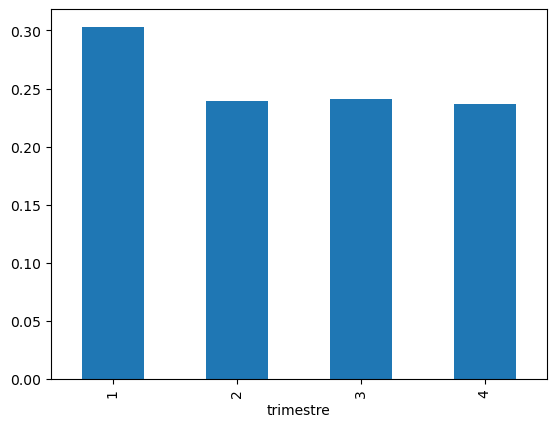

In [20]:
iv_trimestre = ((df_2020_3.pct_evento - df_2020_3.pct_nao_evento)*df_2020_3.WOE).groupby(level=0).sum()
iv_trimestre.plot.bar()

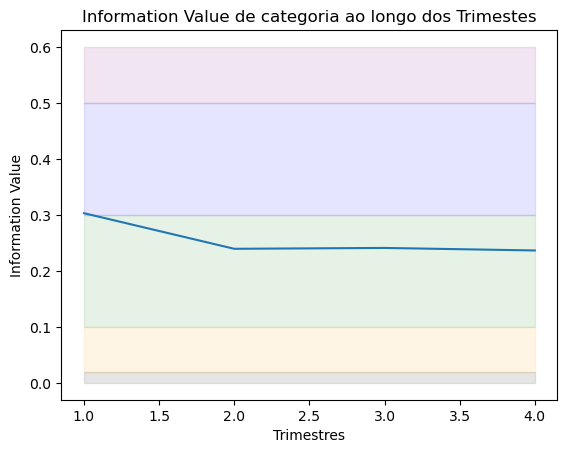

In [21]:
def plot_iv(IV):
    fig, ax = plt.subplots()
    x = IV.index
    a = [.02]*len(IV.index)
    b = [.1]*len(IV.index)
    c = [.3]*len(IV.index)
    d = [.5]*len(IV.index)
    e = [.6]*len(IV.index)

    ax.fill_between(IV.index, a, color='grey', alpha=.2)
    ax.fill_between(IV.index, a, b, color='orange', alpha=.1)
    ax.fill_between(IV.index, b, c, color='green', alpha=.1)
    ax.fill_between(IV.index, c, d, color='blue', alpha=.1)
    ax.fill_between(IV.index, d, e, color='purple', alpha=.1)
    ax.plot(IV)

    ax.set_title("Information Value de categoria ao longo dos Trimestes")
    ax.set_ylabel("Information Value")
    ax.set_xlabel("Trimestres")

plot_iv(iv_trimestre)

## Conclua

- Quais categorias parece ter maior proporção de notas com retornos maiores que zero?
- Essas diferenças são estáveis no tempo?

Dicas:<br>
- Considere que a quantidade de notas vem aumentando
- Considere que há períodos bem atípicos no histórico
- Considere que a partir de janeiro de 2020 o público é mais parecido com o público atual (2022), seja por pandemia, seja por crescimento do público, e considere os dados dessa data em diante na sua conclusão.

* as categorias com maior proprocao de notas sao restaurantes, ramo alimenticios com supermercado, construcao

* as diferenca elas sao estaveis ao longo do tempo considerando no primeiro trimestre do ano que sempre tem uma alta
ao londo do anos si mantem estavel sem muita baixa